# Práctica guiada: reducción de dimensionalidad con PCA

**Entorno recomendado:** Google Colab  
**Dataset:** Wine de `scikit-learn`

## Resultados de aprendizaje
1. Estandarizar variables medidas en escalas diferentes.
2. Aplicar PCA para reducir dimensionalidad.
3. Interpretar la varianza explicada.
4. Analizar una proyección bidimensional.

## Instrucciones
- Ejecute las celdas en orden.
- Complete únicamente las líneas de código indicadas en el Notebook.
- Responda las preguntas que encontrará en Markdowns
- No cambie los nombres de las variables.
- Ejecute la prueba `assert` después de cada actividad.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1. Carga y exploración de los datos

In [3]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target.copy()
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
print("Dimensiones de X:", X.shape)
print("Número de clases:", y.nunique())
display(X.head())

Dimensiones de X: (178, 13)
Número de clases: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
resumen = pd.DataFrame({
    "media": X.mean(),
    "desviación estándar": X.std(),
    "mínimo": X.min(),
    "máximo": X.max()
})
display(resumen.round(3))

,media,desviación estándar,mínimo,máximo
alcohol,13.001,0.812,11.03,14.83
malic_acid,2.336,1.117,0.74,5.80
ash,2.367,0.274,1.36,3.23
alcalinity_of_ash,19.495,3.340,10.60,30.00
magnesium,99.742,14.282,70.00,162.00
total_phenols,2.295,0.626,0.98,3.88
flavanoids,2.029,0.999,0.34,5.08
nonflavanoid_phenols,0.362,0.124,0.13,0.66
proanthocyanins,1.591,0.572,0.41,3.58
color_intensity,5.058,2.318,1.28,13.00


**Pregunta 1.** ¿Las variables se encuentran en escalas similares? Explique por qué esto puede afectar a PCA.

**Respuesta:**

## 2. Estandarización
PCA busca direcciones de máxima varianza. Por eso, una variable con una escala mucho mayor podría dominar el resultado.

In [9]:
# ACTIVIDAD 1
# Utilice StandardScaler para normalizar las variables a (0,1).
scaler = 
# Luego de crear la instancia de StandarScaler aplíquelo a los datos utilizando la función 
# fit_transform para que aplique y transforme los datos al mismo tiempo. 

X_scaled = scaler.

print("Forma:", X_scaled.shape)

Forma: (178, 13)


In [10]:
# PRUEBA 1
assert X_scaled.shape == X.shape
assert np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10)
assert np.allclose(X_scaled.std(axis=0), 1, atol=1e-10)
print("✓ Datos estandarizados correctamente")

✓ Datos estandarizados correctamente


## 3. Aplicación de PCA con dos componentes

In [16]:
# ACTIVIDAD 2
# Aplique PCA seleccionando de una vez los dos primeros componentes principales
pca_2d = PCA( ) # n_componentes = 
X_pca = pca_2d.   #apliquelo con fit_transform
print("Forma:", X_pca.shape)

Forma: (178, 2)


In [17]:
# PRUEBA 2
assert isinstance(pca_2d, PCA)
assert pca_2d.n_components == 2
assert X_pca.shape == (X.shape[0], 2)
assert np.allclose(X_pca.mean(axis=0), 0, atol=1e-10)
print("✓ PCA produjo una representación bidimensional")

✓ PCA produjo una representación bidimensional


## 4. Varianza explicada

In [19]:
# ACTIVIDAD 3
varianza_explicada = pca_2d.explained_variance_ratio_
#varianza_explicada es un vector que contiene la varianza explicada de los dos componentes
print("PC1:", ) 
print("PC2:", )
#Muestre cuál es la varianza acumulada de estas dos variables
print("Varianza acumulada:", )

PC1: 0.362
PC2: 0.1921
Acumulada: 0.5541


In [20]:
# PRUEBA 3
assert len(varianza_explicada) == 2
assert np.all(varianza_explicada >= 0)
assert varianza_explicada[0] >= varianza_explicada[1]
assert 0 < varianza_explicada.sum() <= 1
print("✓ Varianza explicada obtenida correctamente")

✓ Varianza explicada obtenida correctamente


**Pregunta 2.** ¿Qué porcentaje de la variabilidad total conservan PC1 y PC2? ¿Es suficiente para visualizar los datos?

**Respuesta:**

## 5. Visualización

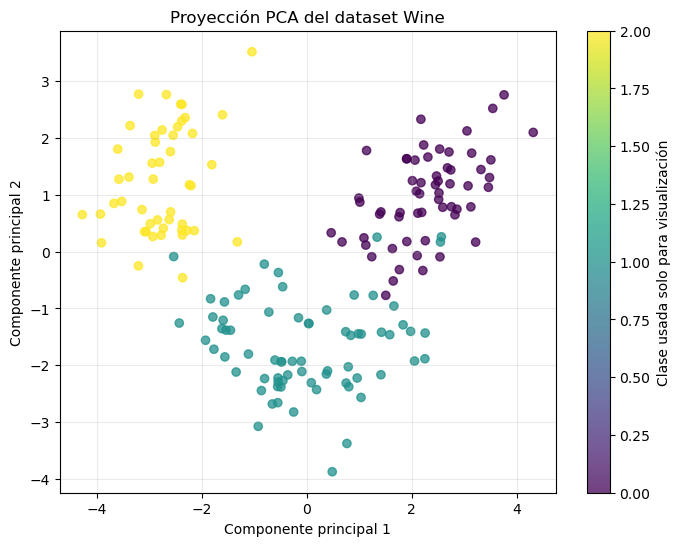

In [21]:
# ACTIVIDAD 4
#Estas instrucciones generan un scattered plot de los datos 
#representados con los dos primeros componentes principales
#Los datos ya transformados se encuentran en X_pca, que es una matriz de (N x 2) 
#donde N es el número de ejemplos

plt.figure(figsize=(8,6))
scatter = plt.scatter( , c=y, alpha=0.75)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Proyección PCA del dataset Wine")
plt.grid(alpha=0.25)
plt.colorbar(scatter, label="Clase usada solo para visualización")
plt.show()

In [22]:
# PRUEBA 4
assert X_pca[:,0].shape[0] == len(y)
assert X_pca[:,1].shape[0] == len(y)
assert not np.allclose(X_pca[:,0], X_pca[:,1])
print("✓ Coordenadas compatibles con la gráfica")

✓ Coordenadas compatibles con la gráfica


**Pregunta 3.** ¿Se observan agrupaciones o superposiciones? ¿La separación visual implica que PCA utilizó las etiquetas?

**Respuesta:**

## 6. Selección del número de componentes

In [26]:
# ACTIVIDAD 5
# Ahora apliquemos PCA sin seleccionar un número de componentes para visualmente seleccionar uno 
# que sea conveniente
pca_total = 
X_pca_total = pca_total.         #fit_transform aplica y transforma los datos de una vez
#Calculemos la varianza acumulada
varianza_acumulada =    #pca_total.explained_variance_ratio_ es un vector con la varianza explicada para cada variable
print(varianza_acumulada)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [27]:
# PRUEBA 5
assert isinstance(pca_total, PCA)
assert len(varianza_acumulada) == X.shape[1]
assert np.all(np.diff(varianza_acumulada) >= -1e-12)
assert np.isclose(varianza_acumulada[-1], 1.0)
print("✓ Varianza acumulada calculada correctamente")

✓ Varianza acumulada calculada correctamente


In [34]:
# ACTIVIDAD 6
#Veamos cuántas componentes se requieren para conservar el 90% de la varianza
pca_90 =     # Aplique PCA nuevamente con n_components=0.90
X_pca_90 = pca_90.         #Aplique fit_transform
k_90 =                  #n_components_ contiene el número de componentes necesarios
print("Componentes para conservar al menos 90 %:", )

Componentes para conservar al menos 90 %: 8


In [35]:
# PRUEBA 6
assert isinstance(k_90, (int, np.integer))
assert 1 <= k_90 <= X.shape[1]
assert varianza_acumulada[k_90-1] >= 0.90
if k_90 > 1: assert varianza_acumulada[k_90-2] < 0.90
print("✓ Número mínimo de componentes identificado")

✓ Número mínimo de componentes identificado


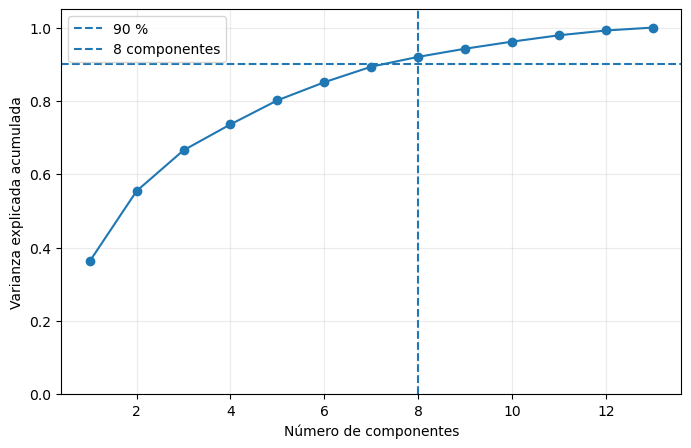

In [36]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(varianza_acumulada)+1), varianza_acumulada, marker="o")
plt.axhline(0.90, linestyle="--", label="90 %")
plt.axvline(k_90, linestyle="--", label=f"{k_90} componentes")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.ylim(0,1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 7. Interpretación de las cargas

In [38]:
cargas = pd.DataFrame(pca_2d.components_.T, index=X.columns, columns=["PC1", "PC2"])
display(cargas.round(3))

,PC1,PC2
alcohol,0.144,0.484
malic_acid,-0.245,0.225
ash,-0.002,0.316
alcalinity_of_ash,-0.239,-0.011
magnesium,0.142,0.300
total_phenols,0.395,0.065
flavanoids,0.423,-0.003
nonflavanoid_phenols,-0.299,0.029
proanthocyanins,0.313,0.039
color_intensity,-0.089,0.530


In [39]:
# ACTIVIDAD 7
# Identifique las tres variables con mayor contribución
# en valor absoluto a la construcción de PC1.
top_pc1 = cargas[ ].abs().sort_values(ascending=False).head(3)
print(top_pc1)

flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
Name: PC1, dtype: float64


In [40]:
# PRUEBA 7
assert len(top_pc1) == 3
assert top_pc1.index.isin(X.columns).all()
assert np.all(np.diff(top_pc1.values) <= 1e-12)
print("✓ Variables con mayor contribución identificadas")

✓ Variables con mayor contribución identificadas


**Pregunta 4.** ¿Qué variables tienen mayor influencia en PC1? Interprete magnitud y signo.

**Respuesta:**

## 8. Conclusiones
Responda brevemente:
1. ¿Por qué se estandarizaron los datos?
2. ¿Qué representa la varianza explicada?
3. ¿Qué información se pierde al conservar dos componentes?
4. ¿PCA garantiza separación de clases?

**Conclusiones:**

# Práctica adicional

Responda las siguientes preguntas adicionales:
1. ¿Qué porcentaje de la varianza conservarían 9 componentes principales?
2. ¿Cuántos componentes principales mínimos requeriria para conservar el 95% de la varianza apróximadamente.

## Extensión opcional: PCA sin estandarizar
Compare el resultado anterior con un PCA aplicado directamente sobre `X`.

In [ ]:
# Extensión opcional: complete libremente.